D:\Anaconda\lib\site-packages\sklearn\utils\validation.py:70: FutureWarning: Pass classes=[0. 1.], y=[0. 0. 0. ... 0. 0. 1.] as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


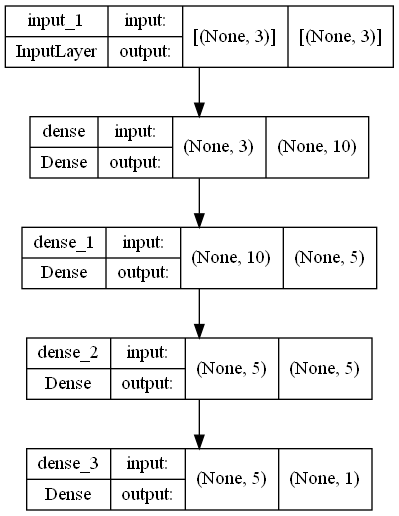

In [1]:
import pandas as pd
import numpy as np
import os
from random import shuffle
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, Input
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import concatenate
from keras.utils.vis_utils import plot_model
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.random
import argparse
import locale
import os

seed = 246

# model-compile parameter sets
model_metrics = 'acc'
epochs = 500
batchs = 64
splits = 0.2
lr        = 3e-4
input_dim = 3
opt = Adam(learning_rate=lr,decay=3e-4/200)

concatenated_df=pd.read_csv("oriI_extraFeatures_Att.csv")
XY = concatenated_df.values
for i in range(10):
    np.random.shuffle(XY)
X = XY[:,[0,2,3]]
Y = XY[:,[5]]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=splits, random_state=seed)

model = Sequential()
inputShape=(input_dim,)
model.add(Input(shape=inputShape))
x = Dense(10,activation="relu", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(model.output)
x = Dense(5,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
x = Dense(5,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
x = Dense(1,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
model = Model(inputs=[model.input],outputs=x)
model.compile(loss="mse",optimizer=opt,metrics=['acc'])

y_train = y_train.flatten()
class_weights = class_weight.compute_class_weight('balanced', np.unique(y_train), y_train)
class_weights = dict(zip(np.unique(y_train),class_weights))

plot_model(model,to_file='FeaturesPlots/model.png',show_shapes=True)

In [2]:
history = model.fit(x=[x_train],y=y_train, validation_data=([x_test], y_test), 
                    epochs=epochs, batch_size=batchs, class_weight=class_weights)

model.save_weights(r'weightANDlearningcurve/AttIModule_model.h5')
eval_model=[]
eval_model.append(model.evaluate([x_test], y_test)[1])
print("\nTest Accuracy: %.4f" % eval_model[0])

Epoch 1/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.1509 - acc: 0.8031 - val_loss: 0.1149 - val_acc: 0.8305
Epoch 2/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0971 - acc: 0.8449 - val_loss: 0.1085 - val_acc: 0.8528
Epoch 3/500
10500/10500 [==============================] - 10s 998us/step - loss: 0.0962 - acc: 0.8498 - val_loss: 0.1047 - val_acc: 0.8573
Epoch 4/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0961 - acc: 0.8498 - val_loss: 0.1106 - val_acc: 0.8498
Epoch 5/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0960 - acc: 0.8494 - val_loss: 0.1027 - val_acc: 0.8586
Epoch 6/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0960 - acc: 0.8496 - val_loss: 0.1104 - val_acc: 0.8503
Epoch 7/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0959 - acc: 0.8493 - val_loss: 0.1119 - val_acc: 0.8463
Epoch 8/500
10500/10500 [=======

10500/10500 [==============================] - 10s 954us/step - loss: 0.0948 - acc: 0.8489 - val_loss: 0.1109 - val_acc: 0.8446
Epoch 60/500
10500/10500 [==============================] - 10s 996us/step - loss: 0.0947 - acc: 0.8488 - val_loss: 0.1045 - val_acc: 0.8528
Epoch 61/500
10500/10500 [==============================] - 10s 1000us/step - loss: 0.0947 - acc: 0.8489 - val_loss: 0.1033 - val_acc: 0.8544
Epoch 62/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0946 - acc: 0.8489 - val_loss: 0.1058 - val_acc: 0.8511
Epoch 63/500
10500/10500 [==============================] - 10s 996us/step - loss: 0.0946 - acc: 0.8493 - val_loss: 0.1087 - val_acc: 0.8471
Epoch 64/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0945 - acc: 0.8495 - val_loss: 0.1110 - val_acc: 0.8441
Epoch 65/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0945 - acc: 0.8493 - val_loss: 0.1113 - val_acc: 0.8451
Epoch 66/500
10500/10500 [=====

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0926 - acc: 0.8540 - val_loss: 0.1051 - val_acc: 0.8525
Epoch 118/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0926 - acc: 0.8542 - val_loss: 0.0998 - val_acc: 0.8563
Epoch 119/500
10500/10500 [==============================] - 10s 999us/step - loss: 0.0926 - acc: 0.8541 - val_loss: 0.1038 - val_acc: 0.8534
Epoch 120/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0926 - acc: 0.8541 - val_loss: 0.1018 - val_acc: 0.8565
Epoch 121/500
10500/10500 [==============================] - 10s 998us/step - loss: 0.0926 - acc: 0.8541 - val_loss: 0.1054 - val_acc: 0.8528
Epoch 122/500
10500/10500 [==============================] - 10s 998us/step - loss: 0.0926 - acc: 0.8541 - val_loss: 0.1058 - val_acc: 0.8511
Epoch 123/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0926 - acc: 0.8540 - val_loss: 0.1007 - val_acc: 0.8572
Epoch 124/500
10500/10500 [=

10500/10500 [==============================] - 10s 999us/step - loss: 0.0925 - acc: 0.8540 - val_loss: 0.1056 - val_acc: 0.8505
Epoch 176/500
10500/10500 [==============================] - 10s 994us/step - loss: 0.0925 - acc: 0.8540 - val_loss: 0.1029 - val_acc: 0.8541
Epoch 177/500
10500/10500 [==============================] - 10s 995us/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1023 - val_acc: 0.8543
Epoch 178/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1039 - val_acc: 0.8521
Epoch 179/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8540 - val_loss: 0.0986 - val_acc: 0.8581
Epoch 180/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8540 - val_loss: 0.1043 - val_acc: 0.8529
Epoch 181/500
10500/10500 [==============================] - 10s 998us/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1047 - val_acc: 0.8514
Epoch 182/500
10500/10500 

10500/10500 [==============================] - 10s 998us/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1029 - val_acc: 0.8544
Epoch 234/500
10500/10500 [==============================] - 10s 999us/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1042 - val_acc: 0.8533
Epoch 235/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1027 - val_acc: 0.8542
Epoch 236/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1008 - val_acc: 0.8555
Epoch 237/500
10500/10500 [==============================] - 10s 993us/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1055 - val_acc: 0.8505
Epoch 238/500
10500/10500 [==============================] - 10s 976us/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1010 - val_acc: 0.8565
Epoch 239/500
10500/10500 [==============================] - 10s 1000us/step - loss: 0.0925 - acc: 0.8540 - val_loss: 0.1074 - val_acc: 0.8500
Epoch 240/500
10500/105

10500/10500 [==============================] - 10s 996us/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1054 - val_acc: 0.8505
Epoch 292/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1027 - val_acc: 0.8541
Epoch 293/500
10500/10500 [==============================] - 10s 999us/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1026 - val_acc: 0.8542
Epoch 294/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8539 - val_loss: 0.1037 - val_acc: 0.8521
Epoch 295/500
10500/10500 [==============================] - 10s 911us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1034 - val_acc: 0.8538
Epoch 296/500
10500/10500 [==============================] - 10s 999us/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1052 - val_acc: 0.8505
Epoch 297/500
10500/10500 [==============================] - 10s 973us/step - loss: 0.0925 - acc: 0.8537 - val_loss: 0.0994 - val_acc: 0.8576
Epoch 298/500
10500/1050

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0925 - acc: 0.8538 - val_loss: 0.1039 - val_acc: 0.8537
Epoch 350/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1031 - val_acc: 0.8539
Epoch 351/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1042 - val_acc: 0.8534
Epoch 352/500
10500/10500 [==============================] - 10s 992us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1044 - val_acc: 0.8529
Epoch 353/500
10500/10500 [==============================] - 10s 987us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1033 - val_acc: 0.8538
Epoch 354/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1040 - val_acc: 0.8537
Epoch 355/500
10500/10500 [==============================] - 10s 953us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1031 - val_acc: 0.8541
Epoch 356/500
10500/10500 [=

10500/10500 [==============================] - 10s 956us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1051 - val_acc: 0.8505
Epoch 408/500
10500/10500 [==============================] - 9s 896us/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1043 - val_acc: 0.8515
Epoch 409/500
10500/10500 [==============================] - 9s 897us/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1041 - val_acc: 0.8537
Epoch 410/500
10500/10500 [==============================] - 9s 896us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1060 - val_acc: 0.8505
Epoch 411/500
10500/10500 [==============================] - 10s 908us/step - loss: 0.0924 - acc: 0.8535 - val_loss: 0.1012 - val_acc: 0.8549
Epoch 412/500
10500/10500 [==============================] - 9s 894us/step - loss: 0.0924 - acc: 0.8539 - val_loss: 0.1056 - val_acc: 0.8510
Epoch 413/500
10500/10500 [==============================] - 9s 898us/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1037 - val_acc: 0.8534
Epoch 414/500
10500/10500

Epoch 465/500
10500/10500 [==============================] - 10s 938us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1050 - val_acc: 0.8509
Epoch 466/500
10500/10500 [==============================] - 10s 921us/step - loss: 0.0924 - acc: 0.8536 - val_loss: 0.1032 - val_acc: 0.8537
Epoch 467/500
10500/10500 [==============================] - 10s 915us/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1037 - val_acc: 0.8533
Epoch 468/500
10500/10500 [==============================] - 10s 913us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1049 - val_acc: 0.8505
Epoch 469/500
10500/10500 [==============================] - 10s 912us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1026 - val_acc: 0.8544
Epoch 470/500
10500/10500 [==============================] - 10s 915us/step - loss: 0.0924 - acc: 0.8538 - val_loss: 0.1021 - val_acc: 0.8542
Epoch 471/500
10500/10500 [==============================] - 10s 918us/step - loss: 0.0924 - acc: 0.8537 - val_loss: 0.1018 - val_acc: 0.8544
Epoch 

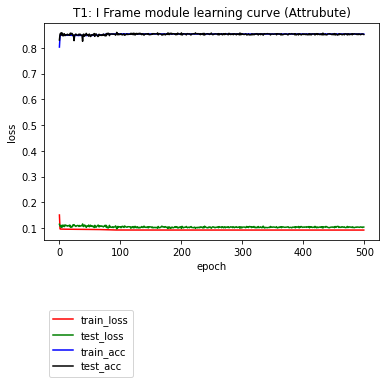

In [3]:
plt.plot(history.history['loss'],color='r')
plt.plot(history.history['val_loss'],color='g')
plt.plot(history.history['acc'],color='b')
plt.plot(history.history['val_acc'],color='k')
plt.title('T1: I Frame module learning curve (Attrubute)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'test_loss','train_acc', 'test_acc'], loc='upper left',bbox_to_anchor=(0,-0.3))
plt.savefig('FeaturesPlots/I_AttTrainingCurve.jpg', bbox_inches='tight', dpi=1280)
plt.show()

import pickle
with open('weightANDlearningcurve/AttIModule_history.txt', 'wb') as file_txt:
    pickle.dump(history.history, file_txt)

In [4]:
np.set_printoptions(suppress=True)

a_weight1=model.get_weights()[0]
a_bias1=model.get_weights()[1]
a_weight2=model.get_weights()[2]
a_bias2=model.get_weights()[3]
a_weight3=model.get_weights()[4]
a_bias3=model.get_weights()[5]


print("\na_weight1: ")
for a in a_weight1:
    for b in a:
        print(b,end=",")
        
print("\n\na_bias1: ")
for a in a_bias1:
        print(a,end=",")
        
print("\n\na_weight2: ")
for a in a_weight2:
    for b in a:
        print(b,end=",")
        
print("\n\na_bias2: ")
for a in a_bias2:
        print(a,end=",")

print("\n\na_weight3: ")
for a in a_weight3:
    for b in a:
        print(b,end=",")
        
print("\n\na_bias3: ")
for a in a_bias3:
        print(a,end=",")


a_weight1: 
0.4404644,0.5098312,-0.007396822,-0.11487717,0.48535517,-0.14654768,-0.2567072,-0.23437792,-0.07800376,-0.0029072105,1.0805368,0.99852556,0.024456704,0.03801262,0.8509048,1.224219,1.4636289,0.6179064,0.028061254,0.023737535,0.43930146,0.6037765,-0.054163266,-0.006955212,0.5017783,-1.018634,-1.0329773,-0.7641678,-0.031430777,-0.024310298,

a_bias1: 
-0.15915392,-0.20950828,-0.03903765,-0.03741286,-0.17415212,0.7373765,0.7410765,0.8252861,-0.059598494,-0.026712874,

a_weight2: 
1.069798,1.0492575,-1.0067143,-0.2184079,-0.30822107,0.94860727,1.0859517,-1.0596362,0.18146466,0.20868951,0.0020064085,0.034179788,0.065355085,0.024081165,0.045235515,-0.038614277,0.044497285,0.03477556,0.061819747,-0.080352865,0.8828288,1.0984412,-1.0008782,0.25015506,0.22609994,-0.20569897,-0.41775435,0.39936078,-3.2854745,-3.1330984,-0.09791576,-0.5564975,0.3399357,-3.5093527,-3.5033443,-0.4287424,-0.6111915,0.61685425,-2.0875092,-2.1380193,0.03607357,-0.047313392,-0.05390205,-0.08838088,0.0069162